# Vision Transformer с нуля на PyTorch

В этой работе нужно реализовать основные части Vision Transformer (ViT): разбиение изображения на патчи, patch embedding, positional embeddings, multi-head self-attention, transformer encoder block и итоговую модель классификации.

**Цель:** понять, как изображение превращается в последовательность токенов и как Transformer применяют к задаче классификации изображений.

## Правила

- Нельзя использовать готовую реализацию ViT из `timm`, `torchvision.models`, HuggingFace и подобных библиотек.
- Можно использовать PyTorch, torchvision datasets/transforms, matplotlib, numpy.
- В основных заданиях attention нужно реализовать вручную.


# 0. Установка и импорты

Если вы работаете в Google Colab, обычно достаточно установить только `torchvision`, если он не установлен.


In [27]:
import math
import random
from dataclasses import dataclass
from typing import Tuple, Optional, Dict, List

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

try:
    import torchvision
    import torchvision.transforms as T
except Exception as e:
    torchvision = None
    T = None
    print("torchvision is not available:", e)


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print("DEVICE:", DEVICE)


DEVICE: cuda


# 1. Идея ViT

Обычная CNN обрабатывает изображение локальными свёртками. Vision Transformer делает иначе:

1. Делит изображение на маленькие квадратные патчи.
2. Каждый патч превращает в вектор — токен.
3. Добавляет positional embedding, чтобы модель знала порядок патчей.
4. Пропускает последовательность токенов через Transformer Encoder.
5. Использует специальный `[CLS]` токен для классификации.

Для изображения размера `H x W` и patch size `P` количество патчей:

$$N =
{H}/{P} \cdot
{W}/{P}$$

Если изображение CIFAR10 имеет размер `32 x 32`, а patch size равен `4`, то получится `8 x 8 = 64` патча.

# Теоретический вопрос 1

1. Зачем нужен токен CLS?
2. В чем идея деления пространства признаков на "головы внимания"?
3. На чем основывается выбор размера патча?

## Ваш ответ:

1. Токен CLS
- Собирает информацию со всех патчей в один вектор для классификации
- Не привязанный к конкретному патчу
- Сам решает, на какие части изображения обращать внимание
Он изначально ничего не знает о картинке, слушает всех остальных, которые смотрят на отдельный кусочек, сам решает, кому больше доверять и формирует финальное мнение для классификации.

2. Параллельное вычисление нескольких независимых механизмов внимания над разными подпространствами признаков.
Каждая голова работает в своем подпространстве признаков, разные головы фокусируются на разных отношениях. Такой подход увеличивает выразительность модели без роста вычислений,а также усреднение по головам стабилизирует обучение.

3.
- Сложность зависит от числа патчей
- Мелкий патч сохраняет детали, крупный дает больше контекста
- Много патчей требуют больше данных для обучения
- Патч должен нести полезную информацию

# 2. Разбиение изображения на патчи

Реализуйте функцию `image_to_patches`.

In [2]:
def image_to_patches(x: torch.Tensor, patch_size: int) -> torch.Tensor:
    """
    Convert batch of images into a batch of flattened patches.

    Args:
        x: Tensor of shape [B, C, H, W]
        patch_size: int, patch size P

    Returns:
        patches: Tensor of shape [B, N, C * P * P]
    """
    B, C, H, W = x.shape
    assert H % patch_size == 0, f"Height {H} must be divisible by patch_size {patch_size}"
    assert W % patch_size == 0, f"Width {W} must be divisible by patch_size {patch_size}"

    N_patch_h = H // patch_size
    N_patch_w = W // patch_size

    x = x.reshape(B, C, N_patch_h, patch_size, N_patch_w, patch_size)
    x = x.permute(0, 2, 4, 1, 3, 5)
    patches = x.reshape(B, N_patch_h * N_patch_w, C * patch_size * patch_size)

    return patches

In [3]:
# Тесты для image_to_patches
x_test = torch.arange(2 * 3 * 8 * 8).float().reshape(2, 3, 8, 8)
patches = image_to_patches(x_test, patch_size=4)
assert patches.shape == (2, 4, 3 * 4 * 4), patches.shape
manual_first_patch = x_test[0, :, 0:4, 0:4].reshape(-1)
assert torch.equal(patches[0, 0], manual_first_patch)
print("image_to_patches tests passed")


image_to_patches tests passed


# 3. Patch Embedding

Далее патчи преобразуем в эмбеддинги длиной embed_dim в `PatchEmbedding`:

`[B, C, H, W] -> [B, N, embed_dim]`


In [4]:
class PatchEmbedding(nn.Module):
    def __init__(self, image_size: int, patch_size: int, in_channels: int, embed_dim: int):
        super().__init__()
        assert image_size % patch_size == 0, "image_size must be divisible by patch_size"
        self.image_size = image_size
        self.patch_size = patch_size
        self.in_channels = in_channels
        self.embed_dim = embed_dim
        self.num_patches = (image_size // patch_size) ** 2
        self.patch_dim = in_channels * patch_size * patch_size

        self.proj = nn.Linear(self.patch_dim, embed_dim)



    def forward(self, x: torch.Tensor) -> torch.Tensor:
        patches = image_to_patches(x, self.patch_size)
        tokens = self.proj(patches)
        return tokens

In [5]:
# Тесты для PatchEmbedding
patch_embed = PatchEmbedding(image_size=32, patch_size=4, in_channels=3, embed_dim=64)
x = torch.randn(5, 3, 32, 32)
out = patch_embed(x)
assert out.shape == (5, 64, 64), out.shape
assert patch_embed.num_patches == 64
print("PatchEmbedding tests passed")


PatchEmbedding tests passed


# 4. Positional Embeddings и CLS token

Transformer сам по себе не знает порядок токенов. Поэтому к токенам добавляют positional embeddings.

Для классификации часто добавляют специальный `[CLS]` токен. После Transformer Encoder берут именно его выход и подают в классификатор.

Реализуйте класс `TokenPreparation`:

```python
patch_tokens: [B, N, D]
output:       [B, N + 1, D]
```


In [6]:
class TokenPreparation(nn.Module):
    def __init__(self, num_patches: int, embed_dim: int):
        super().__init__()
        self.num_patches = num_patches
        self.embed_dim = embed_dim

        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim))


    def forward(self, patch_tokens: torch.Tensor) -> torch.Tensor:
        cls = self.cls_token.expand(patch_tokens.shape[0], -1, -1)
        tokens = torch.cat([cls, patch_tokens], dim=1)
        tokens = tokens + self.pos_embed

        return tokens

In [7]:
# Тесты для TokenPreparation
prep = TokenPreparation(num_patches=64, embed_dim=128)
tokens = torch.randn(2, 64, 128)
out = prep(tokens)
assert out.shape == (2, 65, 128), out.shape
assert isinstance(prep.cls_token, nn.Parameter)
assert isinstance(prep.pos_embed, nn.Parameter)
print("TokenPreparation tests passed")


TokenPreparation tests passed


# 5. Scaled Dot-Product Attention

Реализуйте attention:

$$Attention(Q, K, V) = softmax(
{QK^T}/{\sqrt{d_k}}
)V$$

Вход: `q, k, v: [B, heads, N, head_dim]`

Выход:

- `out: [B, heads, N, head_dim]`
- `attn: [B, heads, N, N]`


In [8]:
def scaled_dot_product_attention(
    q: torch.Tensor,
    k: torch.Tensor,
    v: torch.Tensor,
    dropout: Optional[nn.Module] = None,
) -> Tuple[torch.Tensor, torch.Tensor]:
    head_dim = q.shape[-1]
    scores = q @ k.transpose(-2, -1)
    scores = scores / (head_dim ** 0.5)
    attn = scores.softmax(dim=-1)

    if dropout is not None:
        attn = dropout(attn)
    out = attn @ v

    return out, attn


In [9]:
# Тесты для scaled_dot_product_attention
q = torch.randn(2, 4, 10, 16)
k = torch.randn(2, 4, 10, 16)
v = torch.randn(2, 4, 10, 16)
out, attn = scaled_dot_product_attention(q, k, v)
assert out.shape == (2, 4, 10, 16)
assert attn.shape == (2, 4, 10, 10)
assert torch.allclose(attn.sum(dim=-1), torch.ones_like(attn.sum(dim=-1)), atol=1e-5)
print("scaled_dot_product_attention tests passed")


scaled_dot_product_attention tests passed


# 6. Multi-Head Self-Attention

Реализуйте `MultiHeadSelfAttention`.

Внутри нужно:

1. Получить `qkv` одной линейной проекцией или тремя отдельными.
2. Разделить embedding dimension на `num_heads` голов.
3. Применить scaled dot-product attention.
4. Склеить головы обратно.
5. Применить финальную линейную проекцию.


In [10]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim: int, num_heads: int, attn_dropout: float = 0.0, proj_dropout: float = 0.0):
        super().__init__()
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        self.qkv = nn.Linear(embed_dim, 3 * embed_dim)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.attn_drop = nn.Dropout(attn_dropout)
        self.proj_drop = nn.Dropout(proj_dropout)
        self.last_attention: Optional[torch.Tensor] = None



    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        qkv = self.qkv(x)

        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        out, attn = scaled_dot_product_attention(q, k, v, self.attn_drop)
        self.last_attention = attn.detach()
        out = out.transpose(1, 2).reshape(B, N, D)
        out = self.proj(out)
        out = self.proj_drop(out)
        return out


In [11]:
# Тесты для MultiHeadSelfAttention
mha = MultiHeadSelfAttention(embed_dim=128, num_heads=8)
x = torch.randn(3, 65, 128)
y = mha(x)
assert y.shape == x.shape
assert mha.last_attention is not None
assert mha.last_attention.shape == (3, 8, 65, 65)
print("MultiHeadSelfAttention tests passed")


MultiHeadSelfAttention tests passed


# 7. MLP block

В Transformer Encoder после attention идёт feed-forward network:

`Linear(D, hidden_dim) -> GELU -> Dropout -> Linear(hidden_dim, D) -> Dropout`


In [12]:
class MLP(nn.Module):
    def __init__(self, embed_dim: int, mlp_ratio: float = 4.0, dropout: float = 0.0):
        super().__init__()
        hidden_dim = int(embed_dim * mlp_ratio)
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout)
        )



    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [13]:
# Тесты для MLP
mlp = MLP(embed_dim=128, mlp_ratio=4.0, dropout=0.1)
x = torch.randn(2, 65, 128)
y = mlp(x)
assert y.shape == x.shape
print("MLP tests passed")


MLP tests passed


# 8. Transformer Encoder Block

Реализуйте Pre-LN блок:

```text
x = x + Attention(LayerNorm(x))
x = x + MLP(LayerNorm(x))
```


In [14]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim: int, num_heads: int, mlp_ratio: float = 4.0, dropout: float = 0.0, attn_dropout: float = 0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, attn_dropout, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = MLP(embed_dim, mlp_ratio, dropout)



    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

In [15]:
# Тесты для TransformerEncoderBlock
block = TransformerEncoderBlock(embed_dim=128, num_heads=8, dropout=0.1, attn_dropout=0.1)
x = torch.randn(2, 65, 128)
y = block(x)
assert y.shape == x.shape
print("TransformerEncoderBlock tests passed")


TransformerEncoderBlock tests passed


# 9. Полная модель Vision Transformer

Соберите полный ViT:

1. PatchEmbedding
2. TokenPreparation
3. Несколько TransformerEncoderBlock
4. LayerNorm
5. Classification head


In [16]:
@dataclass
class ViTConfig:
    image_size: int = 32
    patch_size: int = 4
    in_channels: int = 3
    num_classes: int = 10
    embed_dim: int = 128
    depth: int = 4
    num_heads: int = 8
    mlp_ratio: float = 4.0
    dropout: float = 0.1
    attn_dropout: float = 0.1


class VisionTransformer(nn.Module):
    def __init__(self, config: ViTConfig):
        super().__init__()
        self.config = config

        self.patch_embed = PatchEmbedding(config.image_size, config.patch_size, config.in_channels, config.embed_dim)
        self.token_prep = TokenPreparation(self.patch_embed.num_patches, config.embed_dim)
        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(config.embed_dim, config.num_heads,
                                    config.mlp_ratio, config.dropout, config.attn_dropout)
                                    for _ in range(config.depth)
        ])

        self.norm = nn.LayerNorm(config.embed_dim)
        self.head = nn.Linear(config.embed_dim, config.num_classes)
        self.apply(self._init_weights)


    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.trunc_normal_(module.weight, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.LayerNorm):
            nn.init.ones_(module.weight)
            nn.init.zeros_(module.bias)


    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        x = self.patch_embed(x)
        x = self.token_prep(x)
        x = self.dropout(x)
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        cls_token = x[:, 0]
        return cls_token


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.patch_embed(x)
        x = self.token_prep(x)
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        cls_token = x[:, 0]
        logits = self.head(cls_token)
        return logits

In [17]:
# Тесты для VisionTransformer
config = ViTConfig(image_size=32, patch_size=4, embed_dim=128, depth=2, num_heads=8, num_classes=10)
model = VisionTransformer(config)
x = torch.randn(4, 3, 32, 32)
logits = model(x)
assert logits.shape == (4, 10), logits.shape
print("VisionTransformer tests passed")


VisionTransformer tests passed


# 10. Данные CIFAR10

In [18]:
def get_cifar10_loaders(batch_size: int = 128, val_size: int = 5000):
    assert torchvision is not None, "torchvision is required for CIFAR10"
    train_transform = T.Compose([
        T.RandomCrop(32, padding=4),
        T.RandomHorizontalFlip(),
        T.ToTensor(),
        T.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])
    test_transform = T.Compose([
        T.ToTensor(),
        T.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])
    full_train = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
    test_set = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)
    train_size = len(full_train) - val_size
    train_set, val_set = random_split(full_train, [train_size, val_size])
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader, test_loader


# 11. Training loop

Реализуйте функции `train_one_epoch` и `evaluate`.

Требования:

- использовать `model.train()` при обучении;
- использовать `model.eval()` при оценке;
- считать средний loss;
- считать accuracy.


In [19]:
def accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    pred = logits.argmax(dim=1)
    return (pred == y).float().mean().item()


def train_one_epoch(model, loader, optimizer, criterion, device: str) -> Dict[str, float]:
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        batch_size = x.shape[0]

        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_count += batch_size

    return {"loss": total_loss / total_count, "acc": total_correct / total_count}


@torch.no_grad()
def evaluate(model, loader, criterion, device: str) -> Dict[str, float]:
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        batch_size = x.shape[0]

        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_count += batch_size

    return {"loss": total_loss / total_count, "acc": total_correct / total_count}


In [20]:
# Быстрая проверка training loop на случайных данных
class RandomImageDataset(torch.utils.data.Dataset):
    def __init__(self, n=128, num_classes=10):
        self.x = torch.randn(n, 3, 32, 32)
        self.y = torch.randint(0, num_classes, (n,))
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

random_loader = DataLoader(RandomImageDataset(n=64), batch_size=16, shuffle=True)
model = VisionTransformer(ViTConfig(depth=1, embed_dim=64, num_heads=4)).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.05)
criterion = nn.CrossEntropyLoss()
train_metrics = train_one_epoch(model, random_loader, optimizer, criterion, DEVICE)
val_metrics = evaluate(model, random_loader, criterion, DEVICE)
assert "loss" in train_metrics and "acc" in train_metrics
assert "loss" in val_metrics and "acc" in val_metrics
print("training loop tests passed", train_metrics, val_metrics)


training loop tests passed {'loss': 2.3288928270339966, 'acc': 0.125} {'loss': 2.3160860538482666, 'acc': 0.125}


# 12. Запуск обучения

Рекомендуемые параметры для первого запуска:

```python
ViTConfig(image_size=32, patch_size=4, embed_dim=128, depth=4, num_heads=8)
```

Для быстрой проверки можно поставить `depth=2`, `embed_dim=64`, `num_heads=4`.

### Validation acc > 0.6 => 100% score


In [23]:
train_loader, val_loader, test_loader = get_cifar10_loaders(batch_size=128)
config = ViTConfig(image_size=32, patch_size=4, embed_dim=256, depth=8, num_heads=8)
model = VisionTransformer(config).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.05)
criterion = nn.CrossEntropyLoss()
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
epochs = 15
for epoch in range(1, epochs + 1):
    train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_metrics = evaluate(model, val_loader, criterion, DEVICE)
    history["train_loss"].append(train_metrics["loss"])
    history["train_acc"].append(train_metrics["acc"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_acc"].append(val_metrics["acc"])
    print(f"Epoch {epoch:02d}: train loss={train_metrics['loss']:.4f}, train acc={train_metrics['acc']:.4f}, val loss={val_metrics['loss']:.4f}, val acc={val_metrics['acc']:.4f}")


Epoch 01: train loss=1.9697, train acc=0.2678, val loss=1.7763, val acc=0.3368
Epoch 02: train loss=1.6762, train acc=0.3910, val loss=1.6131, val acc=0.4168
Epoch 03: train loss=1.5357, train acc=0.4432, val loss=1.4882, val acc=0.4632
Epoch 04: train loss=1.4559, train acc=0.4728, val loss=1.4248, val acc=0.4832
Epoch 05: train loss=1.3857, train acc=0.4981, val loss=1.3804, val acc=0.4946
Epoch 06: train loss=1.3360, train acc=0.5190, val loss=1.3336, val acc=0.5222
Epoch 07: train loss=1.2975, train acc=0.5325, val loss=1.2838, val acc=0.5422
Epoch 08: train loss=1.2629, train acc=0.5476, val loss=1.2599, val acc=0.5496
Epoch 09: train loss=1.2345, train acc=0.5578, val loss=1.2858, val acc=0.5378
Epoch 10: train loss=1.2082, train acc=0.5687, val loss=1.1914, val acc=0.5754
Epoch 11: train loss=1.1672, train acc=0.5816, val loss=1.1784, val acc=0.5728
Epoch 12: train loss=1.1434, train acc=0.5929, val loss=1.1511, val acc=0.5894
Epoch 13: train loss=1.1092, train acc=0.6013, val l

# 13. Графики обучения

Постройте графики loss и accuracy.


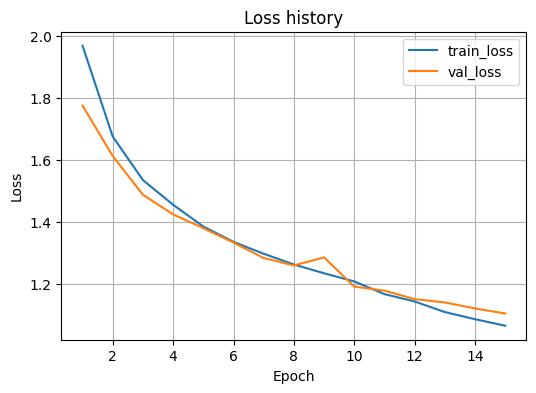

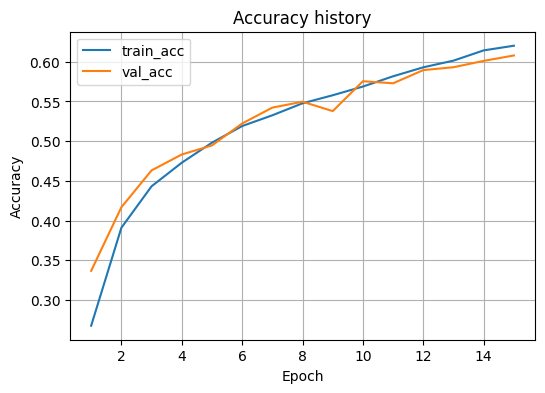

In [24]:
def plot_history(history: Dict[str, List[float]]):
    if not history.get("train_loss"):
        print("History is empty. Train the model first or pass a filled history dictionary.")
        return

    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss history")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy history")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history)


# 14. Дополнительное задание: визуализация attention

После forward pass в каждом attention-блоке сохранено поле `last_attention`.

Форма: `[B, heads, N + 1, N + 1]`

Для визуализации можно взять attention из CLS token к patch tokens:

```python
attn[0, head_id, 0, 1:]
```

Затем reshape в сетку `sqrt(N) x sqrt(N)`.


In [25]:
def get_last_block_cls_attention(model: VisionTransformer, x: torch.Tensor, head_id: int = 0) -> torch.Tensor:
    model.eval()
    with torch.no_grad():
        model(x)
    last_attention = model.blocks[-1].attn.last_attention
    cls_attention = last_attention[0, head_id, 0, 1:]
    N = cls_attention.shape[0]
    grid_size = int(N ** 0.5)
    attention_map = cls_attention.reshape(grid_size, grid_size)
    return attention_map


def visualize_attention_on_image(image: torch.Tensor, attention_map: torch.Tensor):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    img_np = image.permute(1, 2, 0).cpu().numpy()
    img_min = img_np.min()
    img_max = img_np.max()
    if img_max > img_min:
        img_np = (img_np - img_min) / (img_max - img_min)

    ax1.imshow(img_np)
    ax1.set_title("Original Image")
    ax1.axis('off')

    attn_np = attention_map.cpu().numpy()
    im = ax2.imshow(attn_np, cmap='hot', interpolation='nearest')
    ax2.set_title("Attention Map")
    ax2.axis('off')

    plt.colorbar(im, ax=ax2)
    plt.tight_layout()
    plt.show()


Model is on: cuda:0


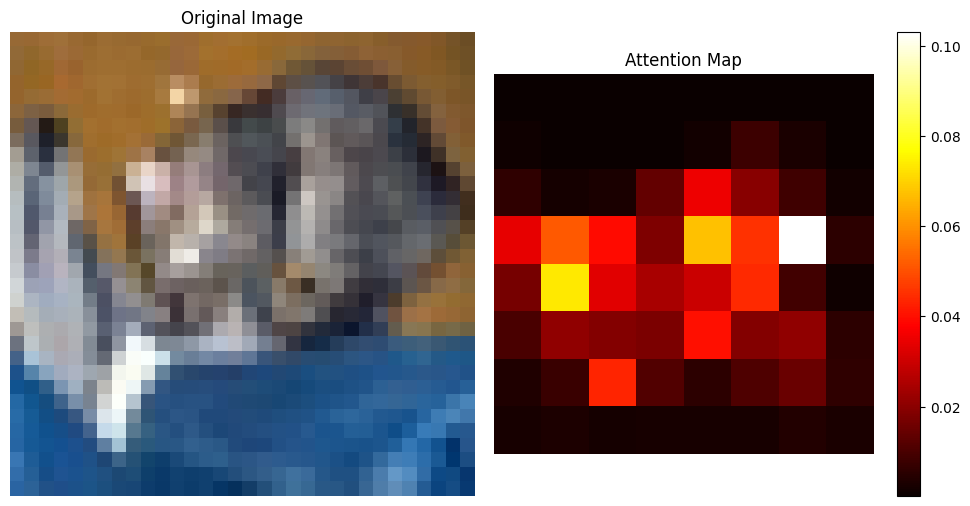

In [29]:
device = next(model.parameters()).device
print(f"Model is on: {device}")

image, label = next(iter(test_loader))
image = image[0:1].to(device)

attn_map = get_last_block_cls_attention(model, image, head_id=0)

image_cpu = image[0].cpu()
attn_map_cpu = attn_map.cpu()

visualize_attention_on_image(image_cpu, attn_map_cpu)

# 16. Вопросы 2

1. Почему сложность self-attention растёт как `O(N^2)` по числу токенов?
2. Почему ViT обычно требует больше данных, чем CNN?
3. Что произойдёт, если убрать residual connections?
4. Что произойдёт, если убрать LayerNorm?


## Ваш ответ:
1. $$Attention(Q, K, V) = softmax({QK^T}/{\sqrt{d_k}})V$$

    $Q$ имеет размер [N, d]

    $K^T$ имеет размер [d, N]

    Получаем [N, N] — матрица, где каждый элемент показывает связь между парой токенов
    
    Чтобы заполнить эту матрицу, нужно N×N вычислений

2. ViT должен всему учиться с нуля, поэтому требуется больше данных

    CNN: свёртка смотрит только на соседние пиксели и один и тот же фильтр применяется ко всему изображению

    ViT: изначально все патчи равноправны и не знают о своём расположении, модель должна сама выучить, что близкие патчи важнее дальних и понять иерархию признаков

3. Сеть станет практически невозможно обучить, резко упадет точность, а градиенты начнут затухать или взрываться из-за проблем с распространением ошибки.

4. Обучение станет крайне нестабильным или полностью остановится. Без нормализации сеть начнет страдать от взрывающихся или затухающих градиентов, а активации будут экспоненциально расти с каждым слоем.